In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.io import imread
import pandas as pd
import os
import glob
from collections import defaultdict
import re
import scanpy as sc


In [4]:
path0 = '../'
panel = pd.read_csv(path0+'/combined_tiff/Leap001/panel.csv',index_col=0)
panel = panel[panel.keep]
base_dir = path0+'split_channels'
file_pattern = '*.tiff'  # Change to '*.tif' if your files have the '.tif' extension

# Create a pattern to search for subdirectories with names starting with 'Leap'
sub_dir_pattern = os.path.join(base_dir, 'Leap*')


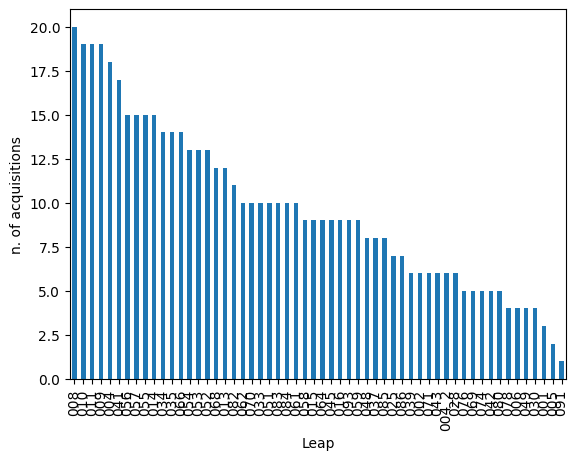

In [6]:
tb = pd.DataFrame(glob.glob(os.path.join(sub_dir_pattern, file_pattern), recursive=True),columns = ['filepath'])
acq_mark = pd.DataFrame(list(tb.filepath.str.split('/').str[-2:]),columns = ['acquisition','marker'])
acq_mark['marker'] = acq_mark.marker.str.rstrip('.tiff')
tb = pd.concat([tb,acq_mark],axis=1)
tb['Leap'] = tb.acquisition.str.split('_').str[:-1].str.join('_')
n_acquisition = (tb.Leap.value_counts()/len(panel))# number of acquisitions per Leap patient
n_acquisition.index = n_acquisition.index.str.replace('Leap','')
n_acquisition.plot(kind = 'bar')

plt.ylabel('n. of acquisitions')
if any(~n_acquisition.apply(float.is_integer)):
    raise ValueError('different number of markers in Leap files:',n_acquisition[n_acquisition.apply(float.is_integer)])

compute the area processed in the acquisition

In [7]:
acq_metadata = pd.read_csv('../IMC_data/acquisition_metadata.csv').iloc[:,1:]
acq_metadata = acq_metadata[acq_metadata.is_valid]
acq_metadata['Leap_ID'] = acq_metadata.source_path.str.replace('^.*?IMC_data/', '',regex = True).str.split('/').str[0]
acq_metadata['area'] =  acq_metadata[['roi_start_x_pos_um',
       'roi_start_y_pos_um', 'roi_end_x_pos_um', 'roi_end_y_pos_um']].apply(lambda x: (x.iloc[2]-x.iloc[0])*(x.iloc[3]-x.iloc[1]), axis = 1)
area = pd.Series(acq_metadata.area.values, index = (acq_metadata.Leap_ID+'_'+acq_metadata.id.astype(str)).values)

Distribution of intensities per marker across all the acquisitions for core

In [43]:
tot_intensity = defaultdict(dict)
for marker,indices in tb.groupby('marker').groups.items():
    # indices are the indicec of tb corresponding to a given marker
    for filepath,acquisition in tb.loc[indices][['filepath','acquisition']].values:
        #read the sum of the expression for marker in filepath
        tot_intensity[marker] |={acquisition:imread(filepath).sum()} 
tot_intensity = pd.DataFrame(tot_intensity)
tot_intensity = tot_intensity.div(area,axis  = 0)

In [10]:
biosamples =pd.read_csv(path0+'IMC_data/ExtraDocs/processed_response.csv')
biosamples.head(1)

,LEAP_ID,SLIDE_NUMBER,BIOBANK_ID,SAMPLE_TYPE_(CORE/RESECTION),FORMAT_(FFPE/FROZEN),FORCE_TRIAL?_(Y/N),DATE_SECTIONED,H&E_NOTES,ST_NOTES,Response,COMMENTS,note_if_frozen_(otherwise_FFPE),Extreme_non-responder_(death_within_2_years?)
0,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,NaN,21/06/2022,NaN,NaN,Non-Responder,core,NaN,NaN


In [44]:
adata = sc.AnnData(X = tot_intensity)
adata.obs['Leap_ID'] = adata.obs.index.str.split('_').str[0].str.upper()
#add biosample metadata
adata.obs = adata.obs.reset_index().merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').set_index('index').drop(['LEAP_ID'],axis = 1)
sc.pp.normalize_total(adata,inplace=True)#using this makes the analysis for the proportion of markers in a pacquisition, rather than the total amount


/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [48]:
#adata.write('tot_intensity_per_acquisition.pkl')

Now run the analysis https://nbisweden.github.io/workshop-scRNAseq/labs/compiled/scanpy/scanpy_05_dge.html

In [49]:
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()

/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [58]:
core

AnnData object with n_obs × n_vars = 308 × 37
    obs: 'Leap_ID', 'SLIDE_NUMBER', 'BIOBANK_ID', 'SAMPLE_TYPE_(CORE/RESECTION)', 'FORMAT_(FFPE/FROZEN)', 'FORCE_TRIAL?_(Y/N)', 'DATE_SECTIONED', 'H&E_NOTES', 'ST_NOTES', 'Response', 'COMMENTS', 'note_if_frozen_(otherwise_FFPE)', 'Extreme_non-responder_(death_within_2_years?)'
    uns: 't-test'

## T-test

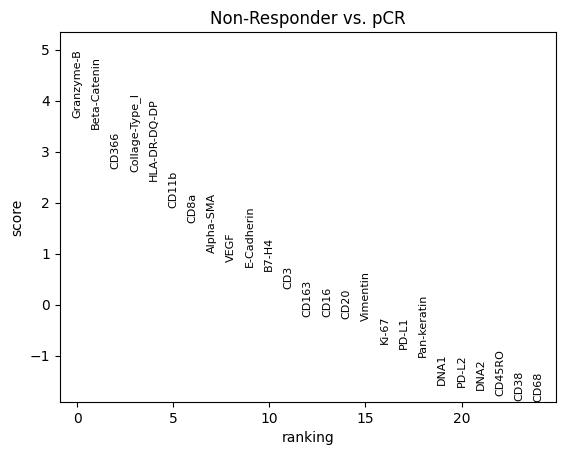

In [50]:

sc.tl.rank_genes_groups(core, groupby='Response',groups=['Non-Responder'],reference='pCR', method='t-test', key_added = "t-test")
sc.pl.rank_genes_groups(core, n_genes=25, sharey=False, key = "t-test")

In [51]:
sc.pl.rank_genes_groups?

## T-test overexpression

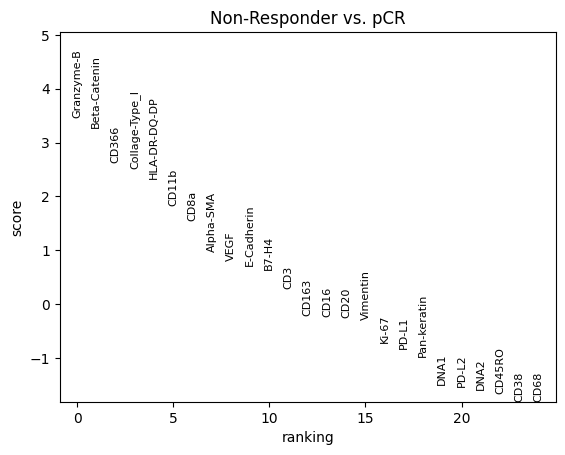

In [411]:
sc.tl.rank_genes_groups(core, groupby='Response', method='t-test_overestim_var',groups=['Non-Responder'],reference='pCR', key_added = "t-test_ov")
sc.pl.rank_genes_groups(core, n_genes=25, sharey=False, key = "t-test_ov")

## wilcoxon

/home/giuseppe/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/tmp/ipykernel_1000092/1793004875.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Statistically significant differentially expressed markers are:
Granzyme-B,Tbe,CD4,FOXP3,CD44


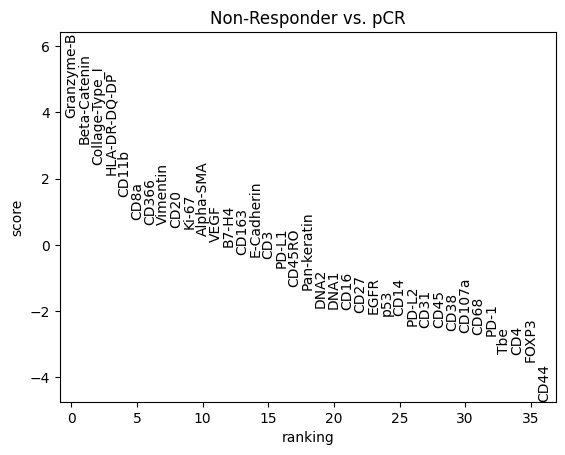

In [72]:

sc.tl.rank_genes_groups(core, groupby='Response',  method='wilcoxon',groups=['Non-Responder'],reference='pCR', key_added = "wilcoxon")
sc.pl.rank_genes_groups(core, n_genes=37, sharey=False, key = "wilcoxon",fontsize=10,show = False)
plt.tight_layout()
#plt.savefig('figures/diff_expr_marker/rank_genes.png')
print('Statistically significant differentially expressed markers are:')
print(*core.uns['wilcoxon']['names']['Non-Responder'][core.uns['wilcoxon']['pvals_adj']['Non-Responder']<0.01],sep = ',')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


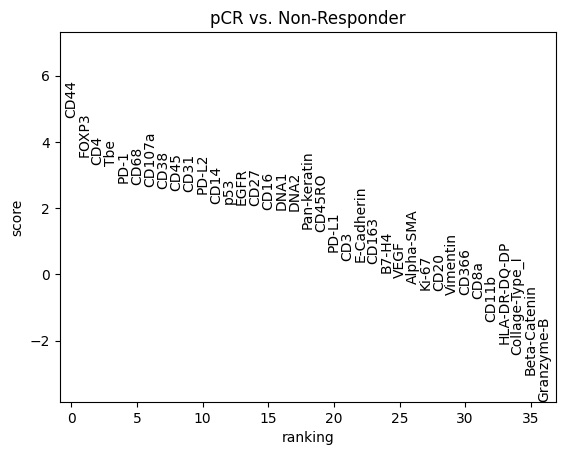

In [75]:
sc.tl.rank_genes_groups(core, groupby='Response',  method='wilcoxon',groups=['pCR'],reference='Non-Responder', key_added = "wilcoxon")
sc.pl.rank_genes_groups(core, n_genes=37, sharey=False, key = "wilcoxon",fontsize=10,show = False)
sc.pl.rank_genes_groups?

In [71]:
sc.get.rank_genes_groups_df(core, group='Non-Responder', key='wilcoxon')

,names,scores,logfoldchanges,pvals,pvals_adj
0,Granzyme-B,3.848690,0.254300,0.000119,0.002197
1,Beta-Catenin,3.043390,0.360721,0.002339,0.014426
2,Collage-Type_I,2.432650,0.393877,0.014989,0.039754
3,HLA-DR-DQ-DP,2.102799,0.290469,0.035483,0.076484
4,CD11b,1.437944,0.072472,0.150450,0.242028
5,CD8a,0.752472,0.062923,0.451767,0.642899
6,CD366,0.621047,0.163518,0.534568,0.690716
7,Vimentin,0.610740,-0.040839,0.541372,0.690716
8,CD20,0.508950,-0.015625,0.610788,0.752889
9,Ki-67,0.480603,-0.090134,0.630799,0.752889


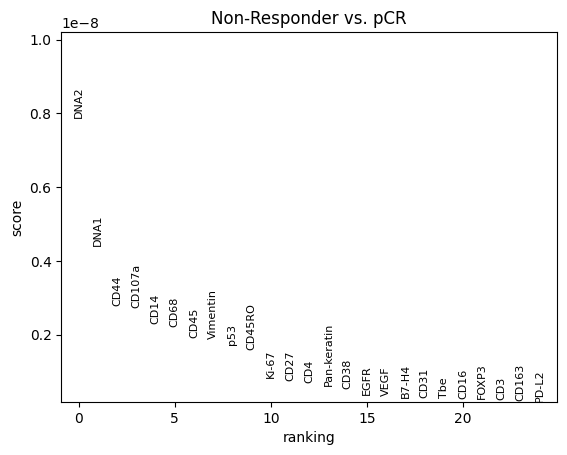

In [494]:

sc.tl.rank_genes_groups(core, groupby='Response', method='logreg',groups=['Non-Responder'],reference='pCR',key_added = "logreg")
sc.pl.rank_genes_groups(core, n_genes=25, sharey=False, key = "logreg")


/home/giuseppe/anaconda3/lib/python3.9/site-packages/matplotlib_venn/_venn3.py:61: UserWarning: Circle C has zero area
  warnings.warn("Circle C has zero area")


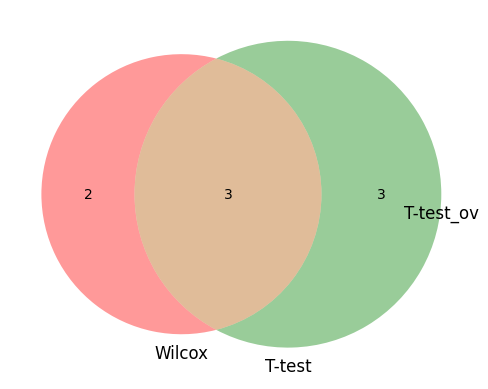

In [434]:
sc.get.rank_genes_groups_df(core, group='Non-Responder', key='wilcoxon')
wc = sc.get.rank_genes_groups_df(core, group='Non-Responder', key='wilcoxon', pval_cutoff=0.01)['names']
tt = sc.get.rank_genes_groups_df(core, group='Non-Responder', key='t-test', pval_cutoff=0.01)['names']
tt_ov = sc.get.rank_genes_groups_df(core, group='Non-Responder', key='t-test_ov', pval_cutoff=0.01)['names']

from matplotlib_venn import venn3

venn3([set(wc),set(tt),set(tt_ov)], ('Wilcox','T-test','T-test_ov') )
plt.show()

In [66]:
core.uns.keys()

odict_keys(['t-test'])

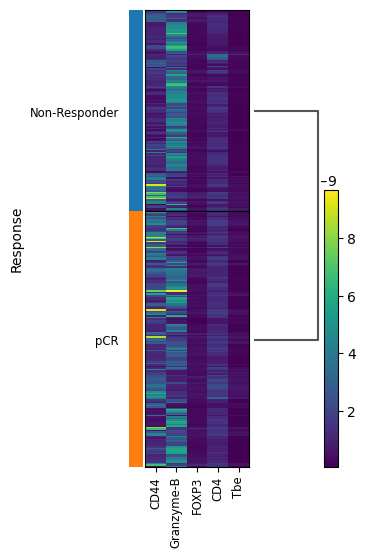

In [448]:
genes_high_pvalue = sc.get.rank_genes_groups_df(core, group='Non-Responder', key='wilcoxon').sort_values('pvals')['names'].iloc[:5].values
sc.pl.rank_genes_groups_heatmap(core,var_names=genes_high_pvalue, key="wilcoxon", groupby="Response", show_gene_labels=True)


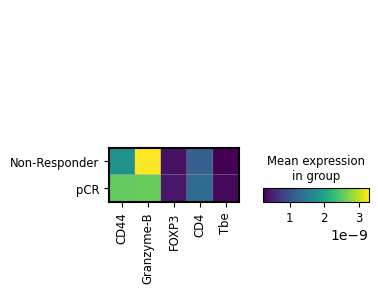

In [461]:
sc.pl.rank_genes_groups_matrixplot(core,  key="wilcoxon", groupby="Response",var_names = genes_high_pvalue)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


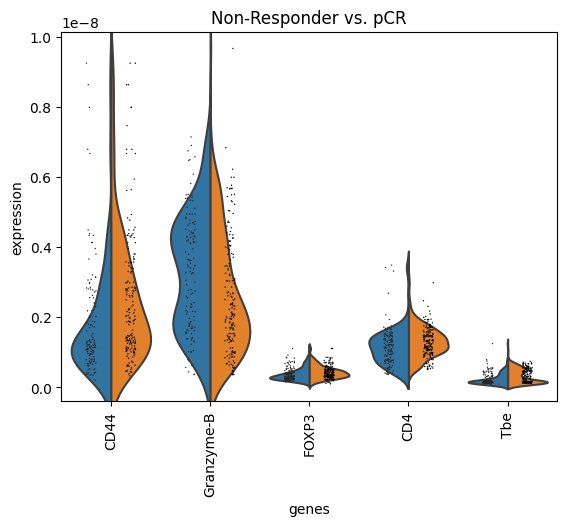

<Figure size 640x480 with 0 Axes>

In [449]:
sc.pl.rank_genes_groups_violin(core,key = 'wilcoxon',gene_names = genes_high_pvalue)
plt.tight_layout()

In [507]:
!mkdir figures/diff_expr_marker

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_46304/934443878.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_46304/934443878.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_46304/934443878.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.

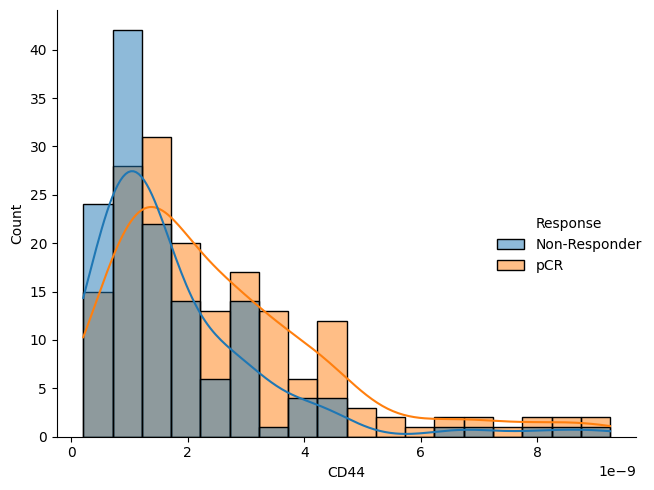

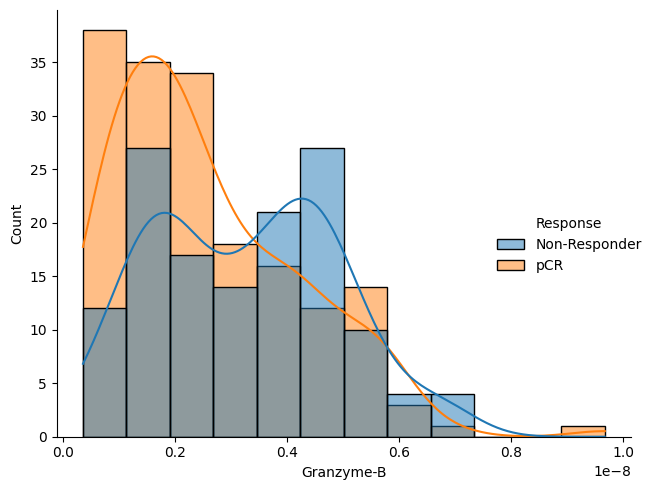

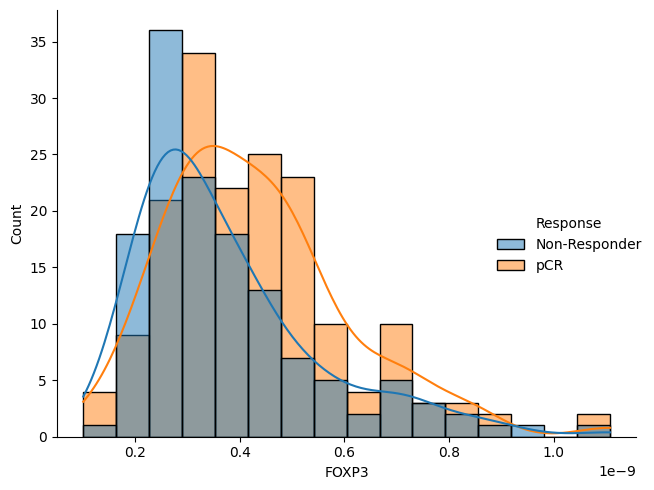

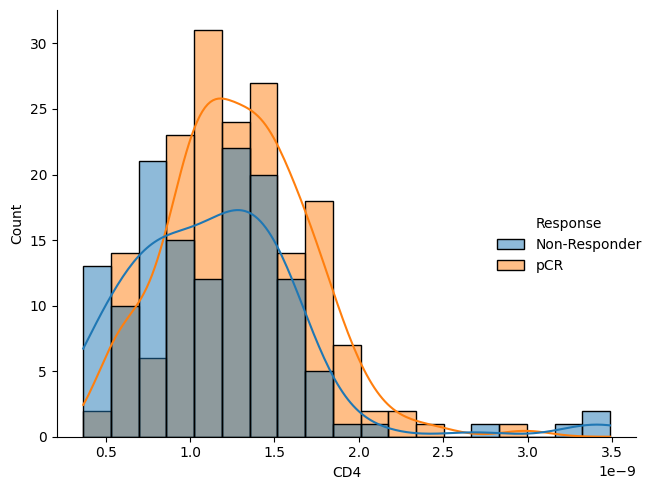

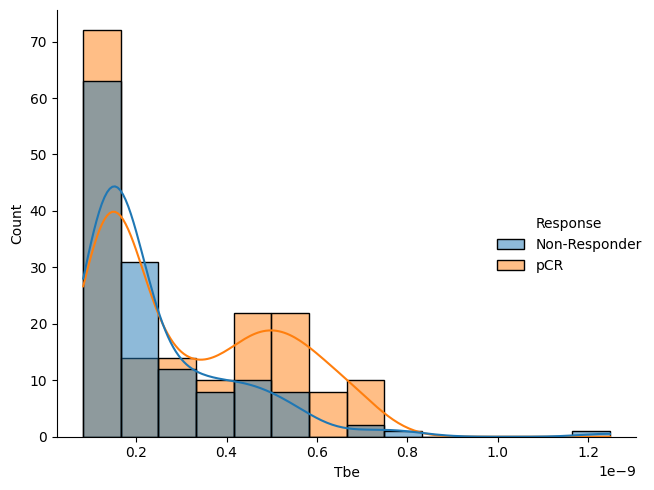

In [508]:
for gene in genes_high_pvalue:
    a = np.ravel(core[:,core.var.index==gene].X[:])
    b = core[:,core.var.index==gene].obs.Response.values
    a = pd.DataFrame(np.vstack((a,b)).T,columns=['expression','Response'])
    sns.displot(data = a,x = 'expression',hue='Response',kde = True)
    plt.tight_layout()
    plt.savefig('figures/diff_expr_marker/'+gene+'.png')
    plt.xlabel(gene)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Axes: xlabel='CD44', ylabel='Density'>

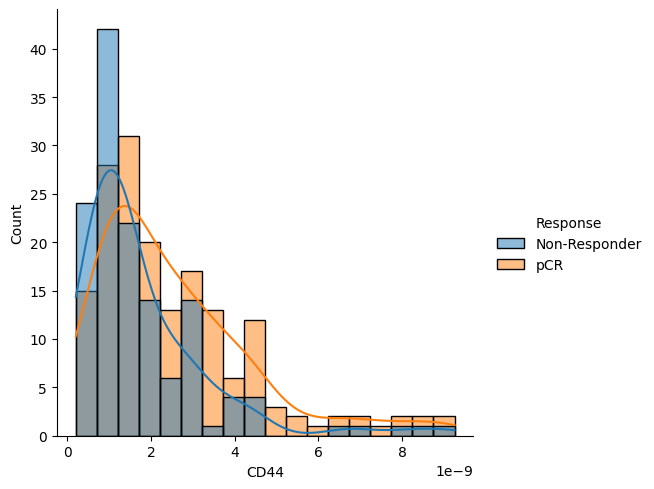

In [457]:
a = np.ravel(core[:,core.var.index=='CD44'].X[:])
b = core[:,core.var.index=='CD44'].obs.Response.values
a = pd.DataFrame(np.vstack((a,b)).T,columns=['expression','Response'])
sns.displot(data = a,x = 'expression',hue='Response',kde = True)

plt.xlabel('CD44')
ax

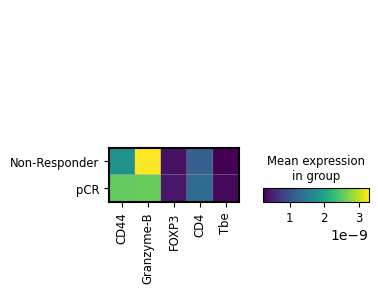

In [460]:
#sc.pl.rank_genes_groups_dotplot(core, n_genes=5, key="wilcoxon", groupby="Response")


/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


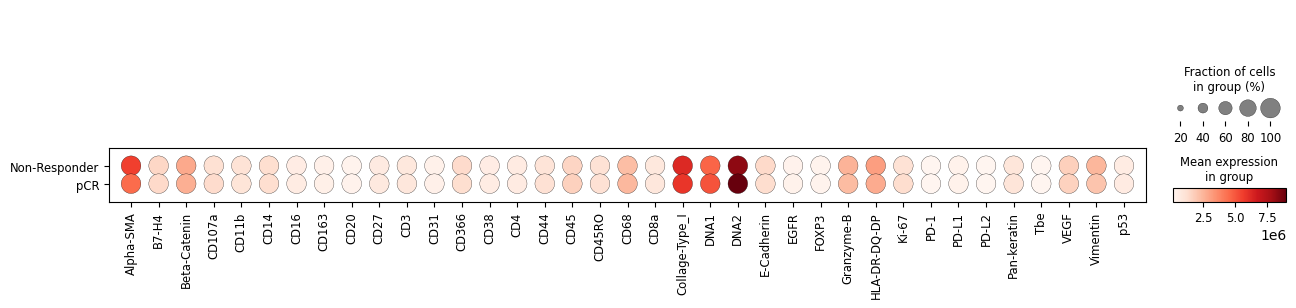

In [551]:
sc.pl.dotplot(adata,adata.var_names, groupby='Response')

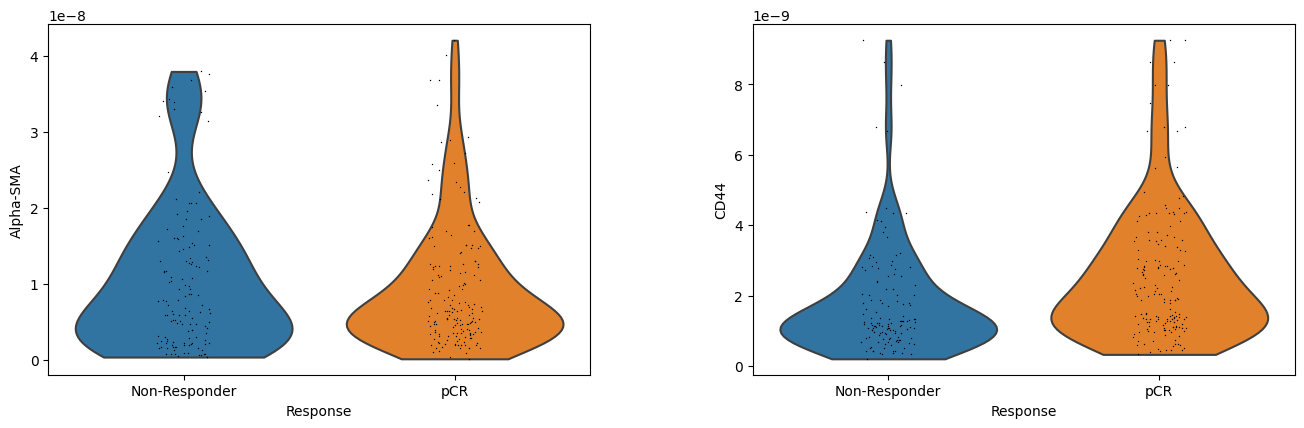

In [466]:
sc.pl.violin(core,['Alpha-SMA','CD44'], groupby='Response')


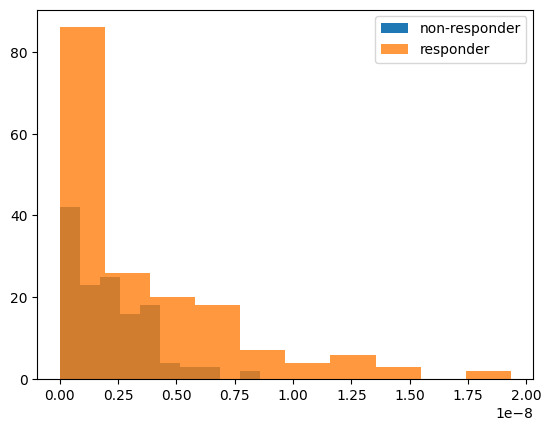

In [250]:
#sns.histplot()
x = core[:,core.var.index == 'CD44']
plt.hist(x[x.obs.Response == 'Non-Responder'].X,label = 'non-responder')
plt.hist(x[x.obs.Response == 'pCR'].X,alpha = 0.8,label = 'responder')
plt.legend()

(array([89., 27., 18., 17.,  7.,  6.,  2.,  2.,  2.,  2.]),
 array([8.63226596e-12, 6.92759639e-09, 1.38465605e-08, 2.07655246e-08,
        2.76844887e-08, 3.46034529e-08, 4.15224170e-08, 4.84413811e-08,
        5.53603452e-08, 6.22793093e-08, 6.91982735e-08]),
 <BarContainer object of 10 artists>)

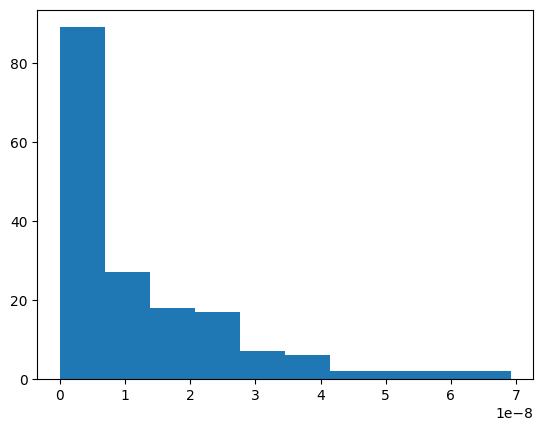

In [205]:
plt.hist(x[x.obs.Response == 'pCR'].X)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


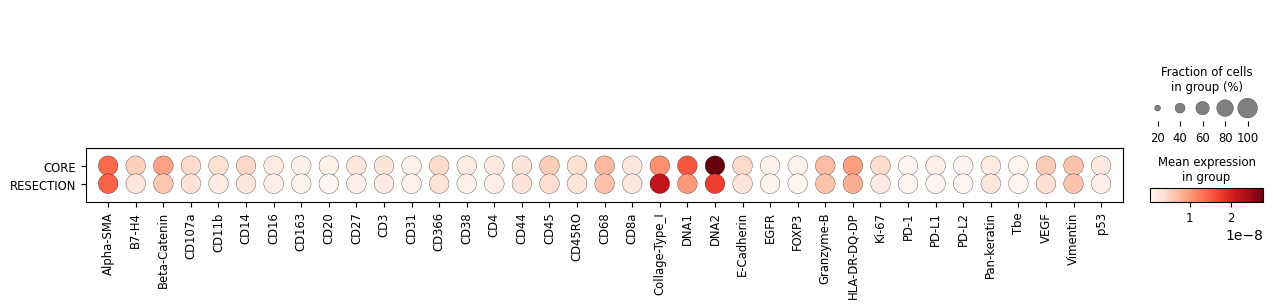

In [40]:
sc.pl.dotplot(adata,adata.var_names, groupby='SAMPLE_TYPE_(CORE/RESECTION)')

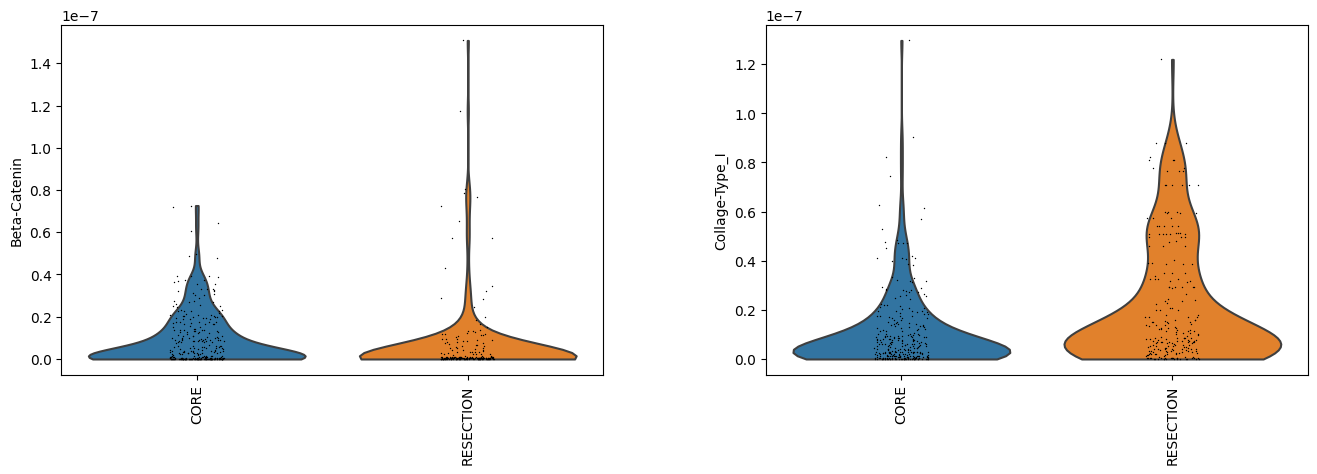

In [43]:
sc.pl.violin(adata,['Beta-Catenin','Collage-Type_I'], groupby='SAMPLE_TYPE_(CORE/RESECTION)', rotation=90)

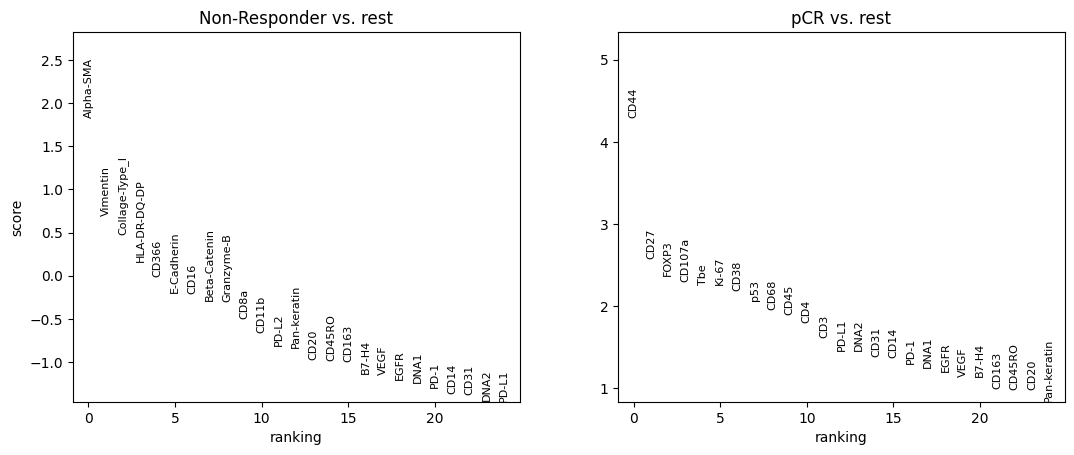

In [64]:
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()
sc.tl.rank_genes_groups(core, groupby='Response', method='t-test', key_added = "t-test")
sc.pl.rank_genes_groups(core, n_genes=25, sharey=False, key = "t-test")

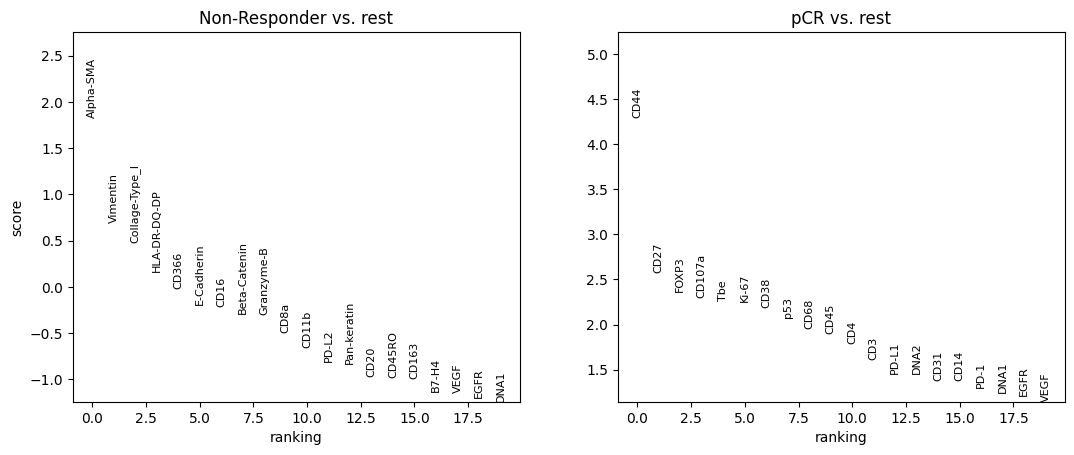

In [66]:
sc.tl.rank_genes_groups(adata, 'louvain_0.6', method='t-test_overestim_var', key_added = "t-test_ov")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key = "t-test_ov")

In [ ]:
sc.tl.rank_genes_groups(adata, groupby='Response', method='t-test', key_added = "t-test")
#sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key = "t-test")

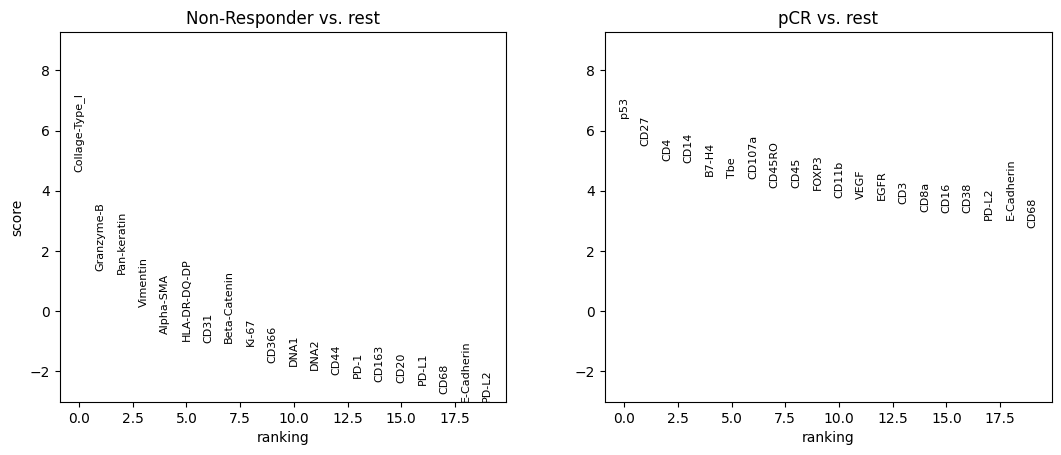

In [71]:
sc.tl.rank_genes_groups(core, groupby='Response', method='wilcoxon')
sc.pl.rank_genes_groups(adata)

<Axes: >

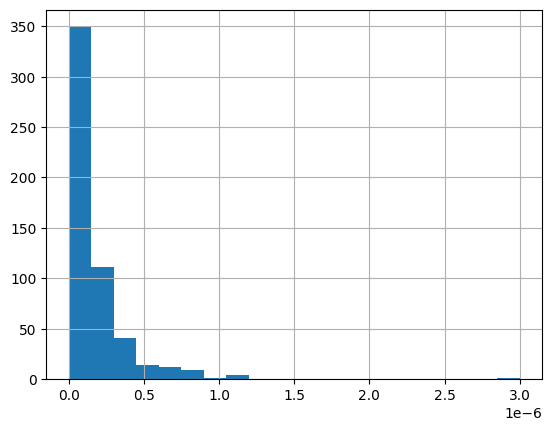

In [70]:
tot_intensity.sum(axis = 1).hist(bins = 20)